In [1]:
# Adjust the working directly to import packages using the root package
import sys
import os
notebook_dir = os.getcwd()
print(notebook_dir)
parent_dir = os.path.dirname(notebook_dir)
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

if "/Users/ashrafahmed/workspace/singular-learning-theory/code/python/" not in sys.path:
    sys.path.insert(0, '/Users/ashrafahmed/workspace/singular-learning-theory/code/python/')

if "/Users/ashrafahmed/workspace/singular-learning-theory/code/python/notebooks" not in sys.path:
    sys.path.insert(0, '/Users/ashrafahmed/workspace/singular-learning-theory/code/python/notebooks')

print(sys.path)

/Users/ashrafahmed/workspace/singular-learning-theory/code/python/notebooks/mixtures/binom2d
['/Users/ashrafahmed/workspace/singular-learning-theory/code/python/notebooks', '/Users/ashrafahmed/workspace/singular-learning-theory/code/python/', '/Users/ashrafahmed/workspace/singular-learning-theory/code/python/notebooks/mixtures', '/opt/miniconda3/lib/python312.zip', '/opt/miniconda3/lib/python3.12', '/opt/miniconda3/lib/python3.12/lib-dynload', '', '/Users/ashrafahmed/workspace/singular-learning-theory/code/python/.venv/lib/python3.12/site-packages']


In [2]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import seaborn as sns
import numpy as np
import pandas as pd

from sklearn_extensions.mixture import BinomialMixture
from sklearn.utils import resample

from IPython.display import display, clear_output
from tqdm.notebook import tqdm

from joblib import Parallel, delayed
import multiprocessing as mp
from notebooks.plot import visualize_joint_confidence_regions
import seaborn as sns
from matplotlib.lines import Line2D
import math

default_palette = 'tab10'
# Enable LaTeX rendering
plt.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'


In [3]:
basedir = "./"

n_trials=100 # number of dna sites checked
num_replications = 1000 # number of samples per sample size
regimes = [50, 250, 5000] # number of samples per trial for each regime

dgps_file = Path(f"{basedir}/data/dgp.csv")
if dgps_file.exists(): # check if this data has already been generated
    print(f"File {dgps_file} exists, skipping experiments meta!.")
else:
    if dgps_file.parent: # create parents dir if not already
        dgps_file.parent.mkdir(parents=True, exist_ok=True)

    dsids = ["regular", "e-singular", "singular1"]
    dgps_raw = {
        "dsid"  : dsids,
        "p0" : np.array([0.35, 0.35, 0.35]), # probability of per site mutation if MSI1 tumor
        "p1" : np.array([0.15, 0.25, 0.35]), # probability of per site mutation if MSI2 tumor
        "w0" : np.array([0.75, 0.75, 0.75]), # probability of selecting a person with MSI1 tumor
    }
    dgps_raw["w1"] = 1-dgps_raw["w0"]
    pd.DataFrame(dgps_raw).set_index("dsid").to_csv(dgps_file)
    print(f"File {dgps_file} created!.")

dgps=pd.read_csv(dgps_file, index_col=0).reset_index()
dgps.head()

File data/dgp.csv created!.


,dsid,p0,p1,w0,w1
0,regular,0.35,0.15,0.75,0.25
1,e-singular,0.35,0.25,0.75,0.25
2,singular1,0.35,0.35,0.75,0.25


In [4]:
data = {}
for dsid in dgps["dsid"].unique():
    data[dsid]={}
    for regime in regimes:
        obs_file = Path(f"{basedir}/data/{dsid}-{regime}.csv") # where we are going to store observations
        if obs_file.exists(): # check if this data has already been generated
            print(f"File {obs_file} exists, skipping random samples creation!.")
        else:
            if obs_file.parent: # create parents dir if not already
                obs_file.parent.mkdir(parents=True, exist_ok=True)
    
            results = {}
            for i in range(num_replications):
                dgp = dgps.query(f"dsid=='{dsid}'")
                weights = dgp[["w0", "w1"]].iloc[0].tolist()
                probs = dgp[["p0", "p1"]].iloc[0].tolist()
                dd = BinomialMixture(n_components=2, weights_init=weights, probs_init=probs, n_trials=n_trials)
                samples = dd.sample(n_samples=regime)
                results[f"r{i}"]=samples[0]
            
            
            data_df = pd.DataFrame(results)
            data_df.to_csv(obs_file, index=False)
            print(f"File {obs_file} created!.")

        data[dsid][regime]=pd.read_csv(obs_file, index_col=0).reset_index()
        dgp = dgps.query(f"dsid == '{dsid}'")
        
        data[dsid]["truth"] = f"$(w_0={dgp['w0'].item()}, p_0={dgp['p0'].item()}, p_1={dgp['p1'].item()})$"

    print(f"Loaded {len(data[dsid])-1} {dsid} datasets")

File data/regular-50.csv created!.
File data/regular-250.csv created!.
File data/regular-5000.csv created!.
Loaded 3 regular datasets
File data/e-singular-50.csv created!.
File data/e-singular-250.csv created!.
File data/e-singular-5000.csv created!.
Loaded 3 e-singular datasets
File data/singular1-50.csv created!.
File data/singular1-250.csv created!.
File data/singular1-5000.csv created!.
Loaded 3 singular1 datasets


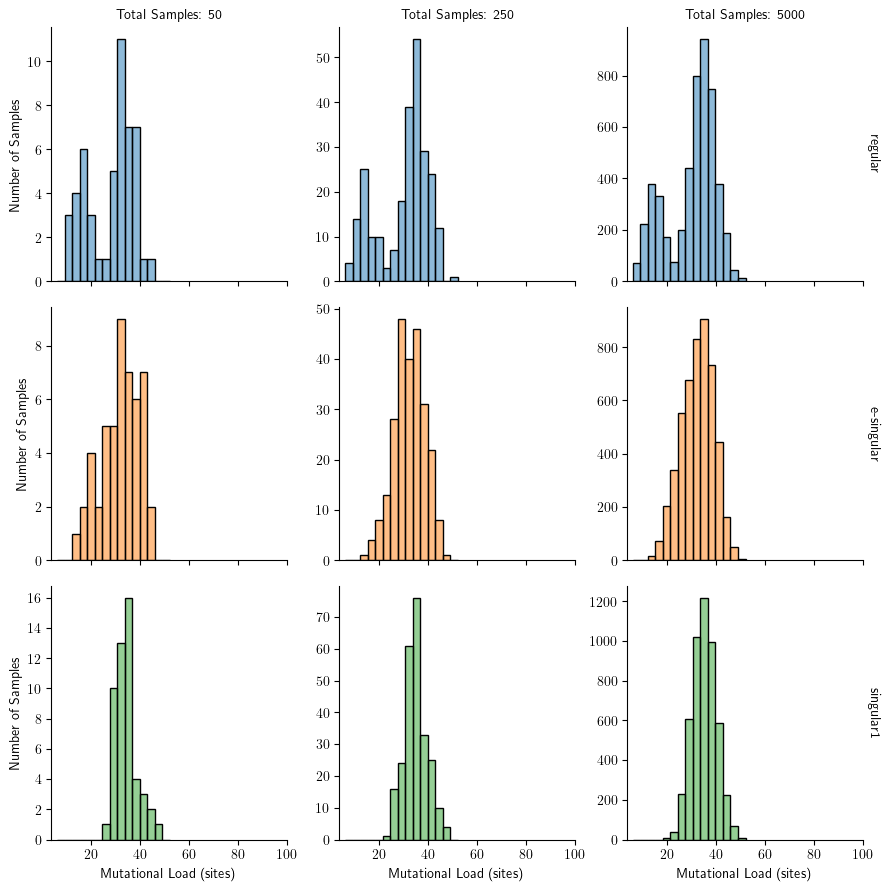

In [6]:
datasets = dgps["dsid"].unique()

# plot the data sets as different sample sizes
# we need to structure the plotting data for different sample sizes (keeping in mind that we are not regenerating the sample in each sample size)
plotdata = {"x": [], "size": [], "dsid": []} # raw data to initialize the plotting dataframe

for dsid in datasets:
    dgp = dgps.query(f"dsid == '{dsid}'")
    for ss in regimes:
        x = data[dsid][ss].iloc[:,0]
        plotdata["x"]=np.append(plotdata["x"], x)
        plotdata["size"]=np.append(plotdata["size"], (np.ones(ss)*ss).astype(int))
        plotdata["dsid"]=np.append(plotdata["dsid"], [dsid for i in np.ones(ss)])

plotdf = pd.DataFrame(plotdata)
plotdf = plotdf.astype({"x": int, "size": int, "dsid": str})
g=sns.displot(plotdf, 
              x="x", col="size", row="dsid", bins=n_trials, hue="dsid",
              binwidth=3, height=3, facet_kws={"margin_titles": True, "sharey": False}, legend=False, palette=default_palette)

g.set_axis_labels("Mutational Load (sites)", "Number of Samples")
g.set_titles(col_template="Total Samples: {col_name}", row_template=f"{{row_name}}")

for ax in g.axes.flat:
    ax.set_xticks(list(range(20, 110, 20)))

datasets_hist_file = Path(f'{basedir}/data/dataset_hist.png')
if datasets_hist_file.parent: # create parents dir if not already
    datasets_hist_file.parent.mkdir(parents=True, exist_ok=True)

plt.savefig(datasets_hist_file, dpi=300, bbox_inches='tight')
plt.show()

In [6]:
import random
# compute the confidence region using gaussian approximation
estimates={"dsid": [], "n": [], "rho1": [], "rho2":[], "p1":[], "p2":[], "confidence_regions": []}
for dsid in datasets:
    for n in tqdm(n_steps, desc=f"n_steps"):
        file = Path(obs_pathstr.format(dsid=dsid, n=n))
        Xs = pd.read_csv(file)
        estimate, model =compute_mle(x_obs=Xs[[f"x_{repl_index}", "n_trials", ]])
        estimates["dsid"].append(dsid)
        estimates["n"].append(n)
        estimates["rho1"].append(estimate["rho1"])
        estimates["rho2"].append(estimate["rho2"])
        estimates["p1"].append(estimate["p1"])
        estimates["p2"].append(estimate["p2"])
        confidence_region_data = model.compute_fisher_confidence_region(Xs[[f"x_{repl_index}", "n_trials", ]])
        estimates["cov_matrix"].append(confidence_region_data["cov_matrix"])
        estimates["chi2_critical"].append(confidence_region_data["chi2_critical"])
        estimates["confidence_level"].append(confidence_region_data["confidence_level"])
        estimates["standard_errors"].append(confidence_region_data["standard_errors"])

estimates

NameError: name 'n_steps' is not defined

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming you have your mle_df dataframe
g = sns.pairplot(
    mle_df[["n", "rho1", "p1", "p2"]].rename(columns={
        'n': 'n',
        'rho1': '$\\rho_1$', 
        'p1': '$p_1$', 
        'p2': '$p_2$'
    }), 
    hue='n',
    hue_order=[1000, 500, 100],  # explicit order
    height=4,
    aspect=1,
    diag_kind="hist",
    plot_kws={
        'alpha': 0.5,
        's': 5,
        'marker': '.',
        'linewidth': 0,  # removes edge lines for cleaner look
    },
    diag_kws={
        'alpha': 0.7,
        'bins': 30,  # if using histograms on diagonal
    }
)

# Set axis labels with LaTeX formatting
# g.set_axis_labels('$p_1$', '$\\rho_1$')

plt.show()

In [ ]:
def resample_and_fit(X, random_state, n_samples, max_iter=10**3, tol=10**3, n_init=1):
    try:
        X_boot = resample(X, random_state=random_state, n_samples=n_samples)
        bmm_boot = BinomialMixture(n_components=2, 
                                   tol=tol, 
                                   max_iter=max_iter,
                                   n_init=n_init)
        
        bmm_boot.fit(X_boot)
        
        if not bmm_boot.converged_:
            raise Error(f"Iteration {i} didn't converge!")

        bmm_boot._enforce_ordering() 
    
        mle = {
            "p1": bmm_boot.probs_[0],
            "p2": bmm_boot.probs_[1], 
            "rho1": bmm_boot.weights_[0],
            "rho2": bmm_boot.weights_[1],
            'iteration': i
        }

    except Exception as e:
        print(f"Error in bootstrap iteration {i}: {e}")
        return None

In [ ]:
##### Set the known variances
n_incr = int(n_samples*1/5)
#partition the total samples into 1/10 increments to show case the impact of number of trials on estimates
n_steps = np.arange(n_incr, n_samples+n_incr, n_incr)
estimates_ts = {}

for e in tqdm(range(total_experiments), desc=f"experiment "):
    w0 = dgp_df.loc[f"{e}"]
    x_obs=(data[[f'{e}_x', f"{e}_n"]]).values
    for i in tqdm(range(len(n_steps)), desc=f"trials "):
        nn = n_steps[i]
        estimates = compute_mle(x_obs=x_obs[:nn],
                                n_bootstrap=10000,
                                max_iter=10**3,
                                tol=10e-3)

        if f"dataset_{e}" not in estimates_ts:
            estimates_ts[f"dataset_{e}"] = { "n":[], "p1": [], "p2": [], "rho1": [], "rho2": []}

        ds = estimates_ts.get(f"dataset_{e}")
        ds["n"].append(nn)
        for pname in ["p1", "p2", "rho1", "rho2"]:
            ss = estimates[pname]["bootstraps"]
            ci_upper = estimates[pname]["ci_upper"]
            ci_lower = estimates[pname]["ci_lower"]
            
            ds[pname].append({
                "mle": estimates[pname]["mle"],
                "bootstraps": estimates[pname]["bootstraps"],
                "ci_lower": ci_lower,
                "ci_upper": ci_upper,
                "boot_min": np.min(estimates[pname]["bootstraps"]),
                "boot_max": np.max(estimates[pname]["bootstraps"])
            })

In [ ]:
# Create DataFrame
dsid = f"dataset_2"
w_true = {
    # "rho1": dgp_df.loc["1", ["rho1"]],
    "rho2": dgp_df.loc["1", ["rho2"]],
    "p1": dgp_df.loc["1", ["p1"]],
    "p2": dgp_df.loc["1", ["p2"]]
}

# for i in range(len(estimates_ts[dsid]["rho1"])):
crdata = pd.DataFrame({
    # 'rho1': estimates_ts[dsid]["rho1"][4]["bootstraps"],
    'rho2': estimates_ts[dsid]["rho2"][1]["bootstraps"], 
    'p1': estimates_ts[dsid]["p1"][1]["bootstraps"],
    'p2': estimates_ts[dsid]["p2"][1]["bootstraps"]
})

# fig, axes = visualize_joint_confidence_regions(crdata, 
#                                           true_params=w_true,
#                                           methods=['kde', 'ellipse']
#                                               )  # Focus on key methods
    
# Create pairplot
g = sns.pairplot(crdata,
                 # corner=True,
                 kind="kde",
                 diag_kind='hist',
                 plot_kws={'levels': [0.68, 0.95, 0.995], 
                           'alpha': 0.6,
                           'fill': True} # Filled contours
                )

# g.set(xlim=(0, 1), ylim=(0, 1))
# Customize the plot
g.fig.suptitle(f'Bootstrap confidence regions, n={estimates_ts[dsid]["n"][i]}')
    
    # print(estimates_ts[dsid]["rho2"][1]["ci_lower"])
    # print(estimates_ts[dsid]["rho2"][1]["ci_upper"])

In [ ]:
# Plot the results
def plot_percentile_results(data, pname):
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    axes = axes.flatten()

    global_min = None
    global_max = None
    for i, dataset in enumerate([f'dataset_{j}' for j in range(0, total_experiments)]):
        ax = axes[i]

        mle = [x["mle"] for x in data[dataset][pname]]
        ci_lower = [x["ci_lower"] for x in data[dataset][pname]]
        ci_upper = [x["ci_upper"] for x in data[dataset][pname]]

        if not global_min:
            global_min = np.min(ci_lower)
        else:
            possible_min = np.min(ci_lower)
            global_min = global_min if global_min < possible_min else possible_min
            
        if not global_max:
            global_max = np.max(ci_upper)
        else:
            possible_max = np.max(ci_upper)
            global_max = global_max if global_max > possible_max else possible_max
        
        x = data[dataset]['n']
        y = mle
        ci_lower = ci_lower
        ci_upper = ci_upper
        
        # Plot estimate
        ax.plot(x, y, 'o-', color='gray', markersize=4)
        
        # Plot confidence interval
        ax.fill_between(x, ci_lower, ci_upper, alpha=0.3, color='pink')
        truth = (dgp_df.loc[f"{i}", [pname]]).item()
        # print(f"dataset={dataset}, truth={truth:0.3f}, mle={data[dataset]['mle'][pname]}")
        ax.axhline(y=truth, color='blue', linestyle='-', linewidth=2, alpha=0.8)
        ax.set_title(f'Dataset {i+1} - 95th Percentile')
        ax.set_xlabel('Sample Size')
        ax.set_ylabel(f'{pname} estimate')
        ax.grid(True, alpha=0.3)

    padding = (global_max-global_min)*0.1
    for ax in axes:
        ax.set_ylim(global_min-padding, global_max+padding)
    
    plt.tight_layout()
    plt.show()

In [ ]:
plot_percentile_results(data=estimates_ts, pname="p1")

In [ ]:
plot_percentile_results(estimates_ts, pname="p2")

In [ ]:
plot_percentile_results(estimates_ts, pname="rho2")